## Logistic Regression: Binary classification

## Overview:

## Logistic Regression is a statistical method used for binary classification, which predicts the probability that a given input belongs to a particular class. 

## Unlike linear regression, which predicts a continuous output, logistic regression applies the logistic function to ensure that the output is a probability value between 0 and 1. This makes it suitable for scenarios where the dependent variable is categorical, often used in applications like spam detection, medical diagnosis, and binary outcome predictions. 

## The model estimates the parameters of a logistic function through maximum likelihood estimation, and these parameters indicate the influence of each predictor variable on the probability of the outcome.

## Importing libraries and data

In [50]:
# Importing libraries
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Importing data
df = pd.read_csv('classification.csv')
df.head()

,age,interest,success
0,23.657801,18.859917,0.0
1,22.573729,17.969223,0.0
2,32.553424,29.463651,0.0
3,6.718035,25.704665,1.0
4,14.401919,16.770856,0.0


In [3]:
# Missing values?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   interest  297 non-null    float64
 2   success   297 non-null    float64
dtypes: float64(3)
memory usage: 7.1 KB


In [4]:
# Statistical information
df.describe()

,age,interest,success
count,297.000000,297.000000,297.000000
mean,23.709718,46.986527,0.569024
std,8.864000,21.956447,0.496049
min,2.347560,-0.852800,0.000000
25%,17.002148,28.689067,0.000000
50%,23.283644,45.695926,1.000000
75%,30.661149,65.171876,1.000000
max,45.773729,97.175508,1.000000


## Visualizing the age and interest of customers by success Success is a binary column:

## 0 = not successful or not sold | 1 = successful or sold

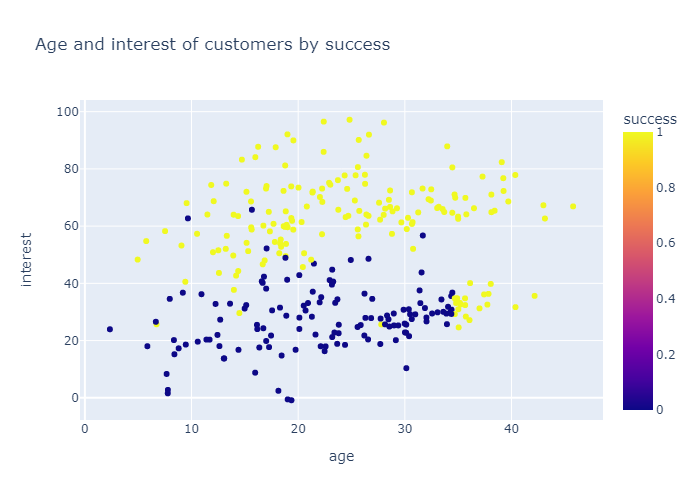

In [54]:
fig = px.scatter(df, x="age", y="interest", color="success", title="Age and interest of customers by success")
fig.show("png")

## Feature scaling:

## Feature scaling is crucial in machine learning because it ensures that all features contribute equally to the model's learning process. Without scaling, features with larger magnitudes can disproportionately influence the model, leading to suboptimal performance. 

## Additionally, many algorithms, like gradient descent-based optimizations and distance-based methods (e.g., k-nearest neighbors, SVM), converge faster and perform better with scaled data.

## In the following code cell, feature scaling will be applied to the data. Then, the scaled data is going to be compared with the original data.

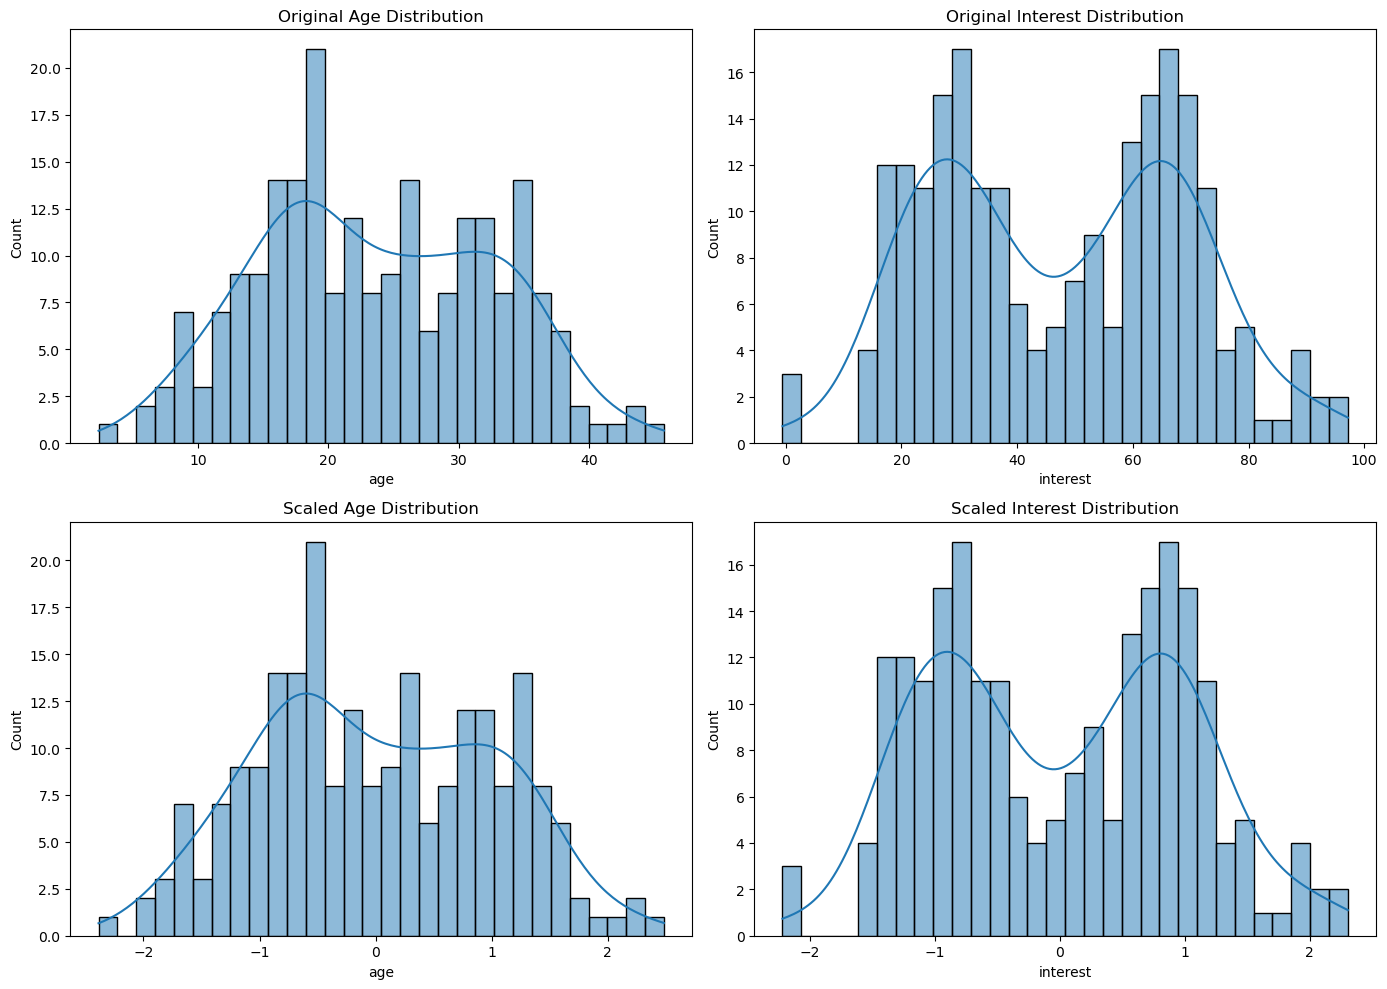

In [68]:
# Defining features
X = df[['age', 'interest']].values
y = df[['success']].values

# Performing the train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

# Scaling the training and testing data
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the data back to DataFrame for visualization
columns = ['age', 'interest']
X_train_df = pd.DataFrame(X_train, columns=columns)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=columns)

# Visualizing the original and scaled data

# Histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original data histograms
sns.histplot(X_train_df['age'], bins=30, ax=axes[0, 0], kde=True)
axes[0, 0].set_title('Original Age Distribution')

sns.histplot(X_train_df['interest'], bins=30, ax=axes[0, 1], kde=True)
axes[0, 1].set_title('Original Interest Distribution')

# Scaled data histograms
sns.histplot(X_train_scaled_df['age'], bins=30, ax=axes[1, 0], kde=True)
axes[1, 0].set_title('Scaled Age Distribution')

sns.histplot(X_train_scaled_df['interest'], bins=30, ax=axes[1, 1], kde=True)
axes[1, 1].set_title('Scaled Interest Distribution')

plt.tight_layout()
plt.show("png")

## As can be seen from these plots, the scaled data retains the original information within the data, but compresses the scale of the data to a format which is more suitable for ML models.

## Now, we can train a Logistic Regression model using the scaled data.

In [63]:
# Instantiate the model
model = LogisticRegression()

# Fitting the scaled data
model.fit(X_train_scaled, y_train)

# Making a prediction on the scaled test data
y_pred = model.predict(X_test_scaled)

## A confusion matrix helps to visualize the accuracy of the model

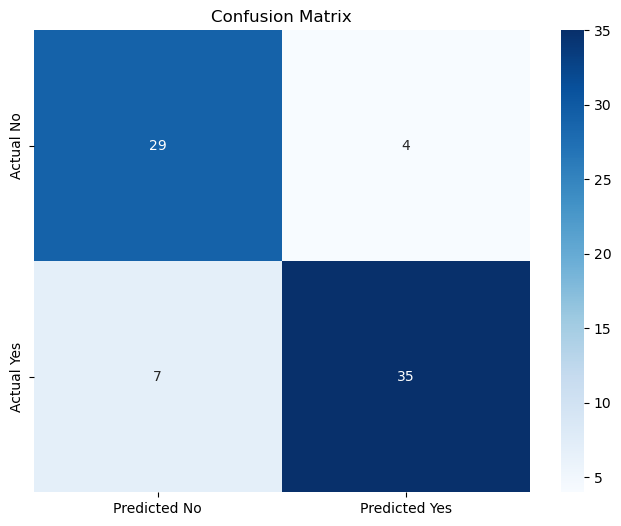

In [67]:
# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted No', 'Predicted Yes'], yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix')
plt.show("png")

## Visualizing the decision boundary of the model

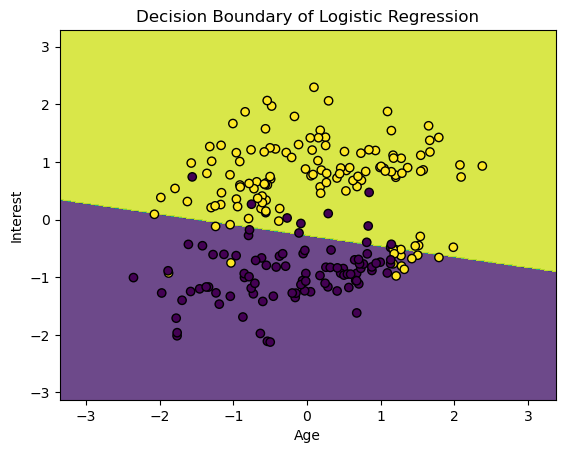

In [66]:
# Define a mesh grid (for 2 features)
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict classifications for each point in the mesh grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the contour and training points
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, edgecolors='k', marker='o')
plt.xlabel('Age')
plt.ylabel('Interest')
plt.title('Decision Boundary of Logistic Regression')
plt.show("png")

## Conclusion:

## The Logistic Regression can be used for many binary classification use cases. Feature scaling will help in building a more robust model since many classification algorithms perform better with scaled data.

## Visualizing the confusion matrix helps to understand, how well the model performed.

## Visualizing the decision boundary of the model demonstrates, how the model works.